# Analysis on Sampling Method.

The goal of this Jupyter Notebook is to examine the dataset produced for ZnO, focusing only on unit cells without random shifts in atomic positions, and identify which lattice parameters were used to populate the dataset. The supercells contained in this dataset will be integer multiples of the values ​​present for the 1x1x1 unit cell. 



This is necessary because, looking back at the [original code](https://github.com/victorccampos/Perseu-ZnO-dataset/blob/d3932647a45eb3d6e3882ba5bbd4e5c5477e85a9/scripts/qeInputBuilder.py#L12) carefully:



```python
strains_a      = setup_strain(relaxed_a)            # a0 · [0.90 … 1.10]
strains_covera = setup_strain(relaxed_c / relaxed_a) # covera0 · [0.90 … 1.10]

# inside get_supercell:
c = a * covera  # → c = (a0·fa) · (covera0·fca) = c0 · fa · fca
```

So the original was **always in the `fa·fca` coupled regime** — the same as my second refactor, never the independent `fc` one. Concretely:

<div align="center">

| Parameter | Original value |
|---|---|
| `new_a` | `a0 · fa` |
| `new_c` | `c0 · fa · fca` ← `a` strain leaks into `c` |

</div>

This means the strain regimes actually sampled were:


1. **Isotropic** → only when `fca = 1.0` (the middle column of the grid). `a` and `c` scale by the same `fa`, so c/a is preserved.


2. **Anisotropic** → all other cases, but with an important asymmetry:
    - `c` is **always more strained than `a`**, because it accumulates both factors.
    - For example at `fa=1.10, fca=1.10`, `a` gets +10% but `c` gets +21%. ***The strain on `c` was never truly independent***.



***Never sampled***:

1. **Pure uniaxial along `c`** (fix `a`, vary only `c`). That would require `fa=1.0, fc≠1.0`, which only the [latest version](https://github.com/victorccampos/Perseu-ZnO-dataset/blob/main/scripts/qeInputBuilder.py) with independent `fc` can express.

2. **Pure biaxial in-plane** (fix `c`, vary only `a`):
    -   **approximately** the `fca=1.0` column, but since `c = a · covera0`, varying `fa` with `fca=1` also moves `c` proportionally — so it's actually isotropic, not biaxial.


In short: the original dataset only sampled **isotropic + a-dominated anisotropic strain**, and since ZnO is known to be stiff along `c` (c > a, large `c`-axis bond), the physically relevant **uniaxial c strain** was never independently explored. 

That's exactly what Example 3 and the latest `fc` parameterization now fix:

```python
 Uniaxial along c only
     for fc in STRAIN_C:
         sc = build_structure(ref, shape=(1, 1, 2), fa=1.0, fc=fc)
         write_structure(sc, make_fname((1,1,2), 1.0, fc, 0.0), QE_CONFIG, BASE_K)
```


---

In [1]:
from pathlib import Path

from ase.io import read
from ase import Atoms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("../mpl_themes/jvc.mplstyle")

Meu template seria o arquivo: `LDA-0781-ZnO-111-fa1.00-fc1.00-n0.000.xsf` com:
- $a = 3.2\AA$
- $c=5.13 \AA$

In [2]:
# Paths
# train        = 6254 estruturas (Original Sampling)
# subset1      = 221  (1x1x8)
# subset2      = 49   (2x1x4)
# subset3      = 78   (3x3x3)
# normal_modes = 10
# -----------------------------------
# 6612 estruturas.

data = Path("/home/jvc/ZnO_database/data")

train = data / "dataset" / "01_LDA_dataset_filtered" / "train"

complete_dataset: Path = train.parent.parent / "01_LDA_dataset"


# Files of unit cells with no random displacements.
unit_cell_files: list[Path] = [
    file for d in [complete_dataset] for file in sorted(d.glob("*ZnO-111-*-n0.000.xsf"))
]
unit_cell_atoms: list[Atoms] = [read(f) for f in unit_cell_files]


In [3]:

print(*unit_cell_files[:3], sep="\n")
print()
print(*unit_cell_atoms[:3], sep="\n")

/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0001-ZnO-111-fa0.90-fc0.90-n0.000.xsf
/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0014-ZnO-111-fa0.90-fc0.92-n0.000.xsf
/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0027-ZnO-111-fa0.90-fc0.94-n0.000.xsf

Atoms(symbols='Zn2O2', pbc=True, cell=[[2.876560207838307, 0.0, 0.0], [-1.4382801039191535, 2.49117305399317, 0.0], [0.0, 0.0, 4.156482795755754]], calculator=SinglePointCalculator(...))
Atoms(symbols='Zn2O2', pbc=True, cell=[[2.876560207838307, 0.0, 0.0], [-1.4382801039191535, 2.49117305399317, 0.0], [0.0, 0.0, 4.248849144029442]], calculator=SinglePointCalculator(...))
Atoms(symbols='Zn2O2', pbc=True, cell=[[2.876560207838307, 0.0, 0.0], [-1.4382801039191535, 2.49117305399317, 0.0], [0.0, 0.0, 4.34121549230313]], calculator=SinglePointCalculator(...))


In [4]:
unit_cell_data = {
    "filenames": [f.name for f in unit_cell_files],
    "atoms": unit_cell_atoms,
}

df_unit_cell = pd.DataFrame(unit_cell_data)
display(df_unit_cell)

,filenames,atoms
0,LDA-0001-ZnO-111-fa0.90-fc0.90-n0.000.xsf,"(Atom('Zn', [-0.0, 1.660782898964, 4.155833556..."
1,LDA-0014-ZnO-111-fa0.90-fc0.92-n0.000.xsf,"(Atom('Zn', [-0.0, 1.660782898964, 4.248185521..."
2,LDA-0027-ZnO-111-fa0.90-fc0.94-n0.000.xsf,"(Atom('Zn', [-0.0, 1.660782898964, 4.340537487..."
3,LDA-0040-ZnO-111-fa0.90-fc0.96-n0.000.xsf,"(Atom('Zn', [-0.0, 1.660782898964, 4.432889164..."
4,LDA-0053-ZnO-111-fa0.90-fc0.98-n0.000.xsf,"(Atom('Zn', [-0.0, 1.660782898964, 4.525241130..."
...,...,...
116,LDA-1509-ZnO-111-fa1.10-fc1.02-n0.000.xsf,"(Atom('Zn', [-0.0, 2.029846003027, 5.756599841..."
117,LDA-1522-ZnO-111-fa1.10-fc1.04-n0.000.xsf,"(Atom('Zn', [-0.0, 2.029846003027, 5.869474479..."
118,LDA-1535-ZnO-111-fa1.10-fc1.06-n0.000.xsf,"(Atom('Zn', [-0.0, 2.029846003027, 5.982348765..."
119,LDA-1548-ZnO-111-fa1.10-fc1.08-n0.000.xsf,"(Atom('Zn', [-0.0, 2.029846003027, 6.095223403..."


In [5]:
# x here is a Atoms obj from ASE 
df_unit_cell["a"] = df_unit_cell["atoms"].apply(lambda x: x.cell[0][0])
df_unit_cell["c"] = df_unit_cell["atoms"].apply(lambda x: x.cell[2][2])

In [6]:
unique_a = sorted(df_unit_cell["a"].unique())
unique_c = sorted(df_unit_cell["c"].unique())


print(f"Unique values of a ({len(unique_a)}):\n{unique_a}")
print(f"Unique values of c ({len(unique_c)}):\n{unique_c}")

Unique values of a (11):
[2.876560207838307, 2.9404842854302067, 3.004407833844898, 3.068331382259589, 3.13225493067428, 3.196178479088971, 3.2601020275036623, 3.3240255759183532, 3.387949124333044, 3.4518726727477356, 3.5157962211624265]
Unique values of c (121):
[4.156482795755754, 4.248849144029442, 4.248849827748092, 4.34121549230313, 4.341216095106351, 4.343268778153256, 4.433581840576818, 4.433582362464611, 4.437687630651111, 4.437687728558419, 4.5259481888505055, 4.52594862982287, 4.532106483148966, 4.532106678963584, 4.534159166195871, 4.618314537124194, 4.618314897181129, 4.626525335646821, 4.626525629368747, 4.630630603833322, 4.630630701740631, 4.710680885397882, 4.710681164539389, 4.720944188144676, 4.720944579773912, 4.727102041470772, 4.72710223728539, 4.729154724517677, 4.80304723367157, 4.803047431897649, 4.815363040642532, 4.815363530179075, 4.823573479108223, 4.82357377283015, 4.827678747294724, 4.8276788452020325, 4.89541070538505, 4.895413699255908, 4.90978189314038

In [7]:
# 11 a's to 11 c's
df_unit_cell.groupby("a")[["c"]].count()

,c
a,
2.876560,11
2.940484,11
3.004408,11
3.068331,11
3.132255,11
3.196178,11
3.260102,11
3.324026,11
3.387949,11


In [8]:
df_unit_cell["strain_a (%)"] = ((df_unit_cell["a"] - 3.20) / 3.20) * 100
df_unit_cell["strain_c (%)"] = ((df_unit_cell["c"] - 5.13) / 5.13) * 100
df_unit_cell["strain_a (%)"] = df_unit_cell["strain_a (%)"]
df_unit_cell["strain_c (%)"] = df_unit_cell["strain_c (%)"]


In [9]:
# TEMPLATE STRUCTURE

print("-" * 80)
print("Equilibrium Structure\n")
print(df_unit_cell.iloc[60])

print("-" * 80)
print("Forces acting on atoms (eV/angstrom):\n")
print(df_unit_cell.iloc[60]["atoms"].get_forces())
print("-" * 80)


--------------------------------------------------------------------------------
Equilibrium Structure

filenames               LDA-0781-ZnO-111-fa1.00-fc1.00-n0.000.xsf
atoms           (Atom('Zn', [-0.0, 1.845314603756, 5.130659750...
a                                                        3.196178
c                                                        5.131461
strain_a (%)                                            -0.119423
strain_c (%)                                             0.028486
Name: 60, dtype: object
--------------------------------------------------------------------------------
Forces acting on atoms (eV/angstrom):

[[ 0.          0.          0.00204293]
 [-0.          0.          0.00204293]
 [ 0.          0.         -0.00204293]
 [ 0.          0.         -0.00204293]]
--------------------------------------------------------------------------------


In [10]:
amin = df_unit_cell["a"].min()
amax = df_unit_cell["a"].max()


cmin = df_unit_cell["c"].min()
cmax = df_unit_cell["c"].max()

min_strain_a = df_unit_cell["strain_a (%)"].min()
max_strain_a = df_unit_cell["strain_a (%)"].max()

min_strain_c = df_unit_cell["strain_c (%)"].min()
max_strain_c = df_unit_cell["strain_c (%)"].max()


In [11]:


print("Interval of Lattice parameter a:")
print(f"min, max = {amin, amax}")
print("="*80)

print("Interval of Lattice parameter c:")
print(f"min, max = {cmin, cmax}")
print("="*80)


print("Interval of strain (%) for lattice parameter a:")
print(f"min, max = {min_strain_a, min_strain_a}")


print("="*80)
print("Interval of strain (%) for lattice parameter c:")
print(f"min, max = {min_strain_c, min_strain_c}")



Interval of Lattice parameter a:
min, max = (2.876560207838307, 3.5157962211624265)
Interval of Lattice parameter c:
min, max = (4.156482795755754, 6.209064884791461)
Interval of strain (%) for lattice parameter a:
min, max = (-10.107493505052911, -10.107493505052911)
Interval of strain (%) for lattice parameter c:
min, max = (-18.97694355251941, -18.97694355251941)


## Lattice Parameter Grid

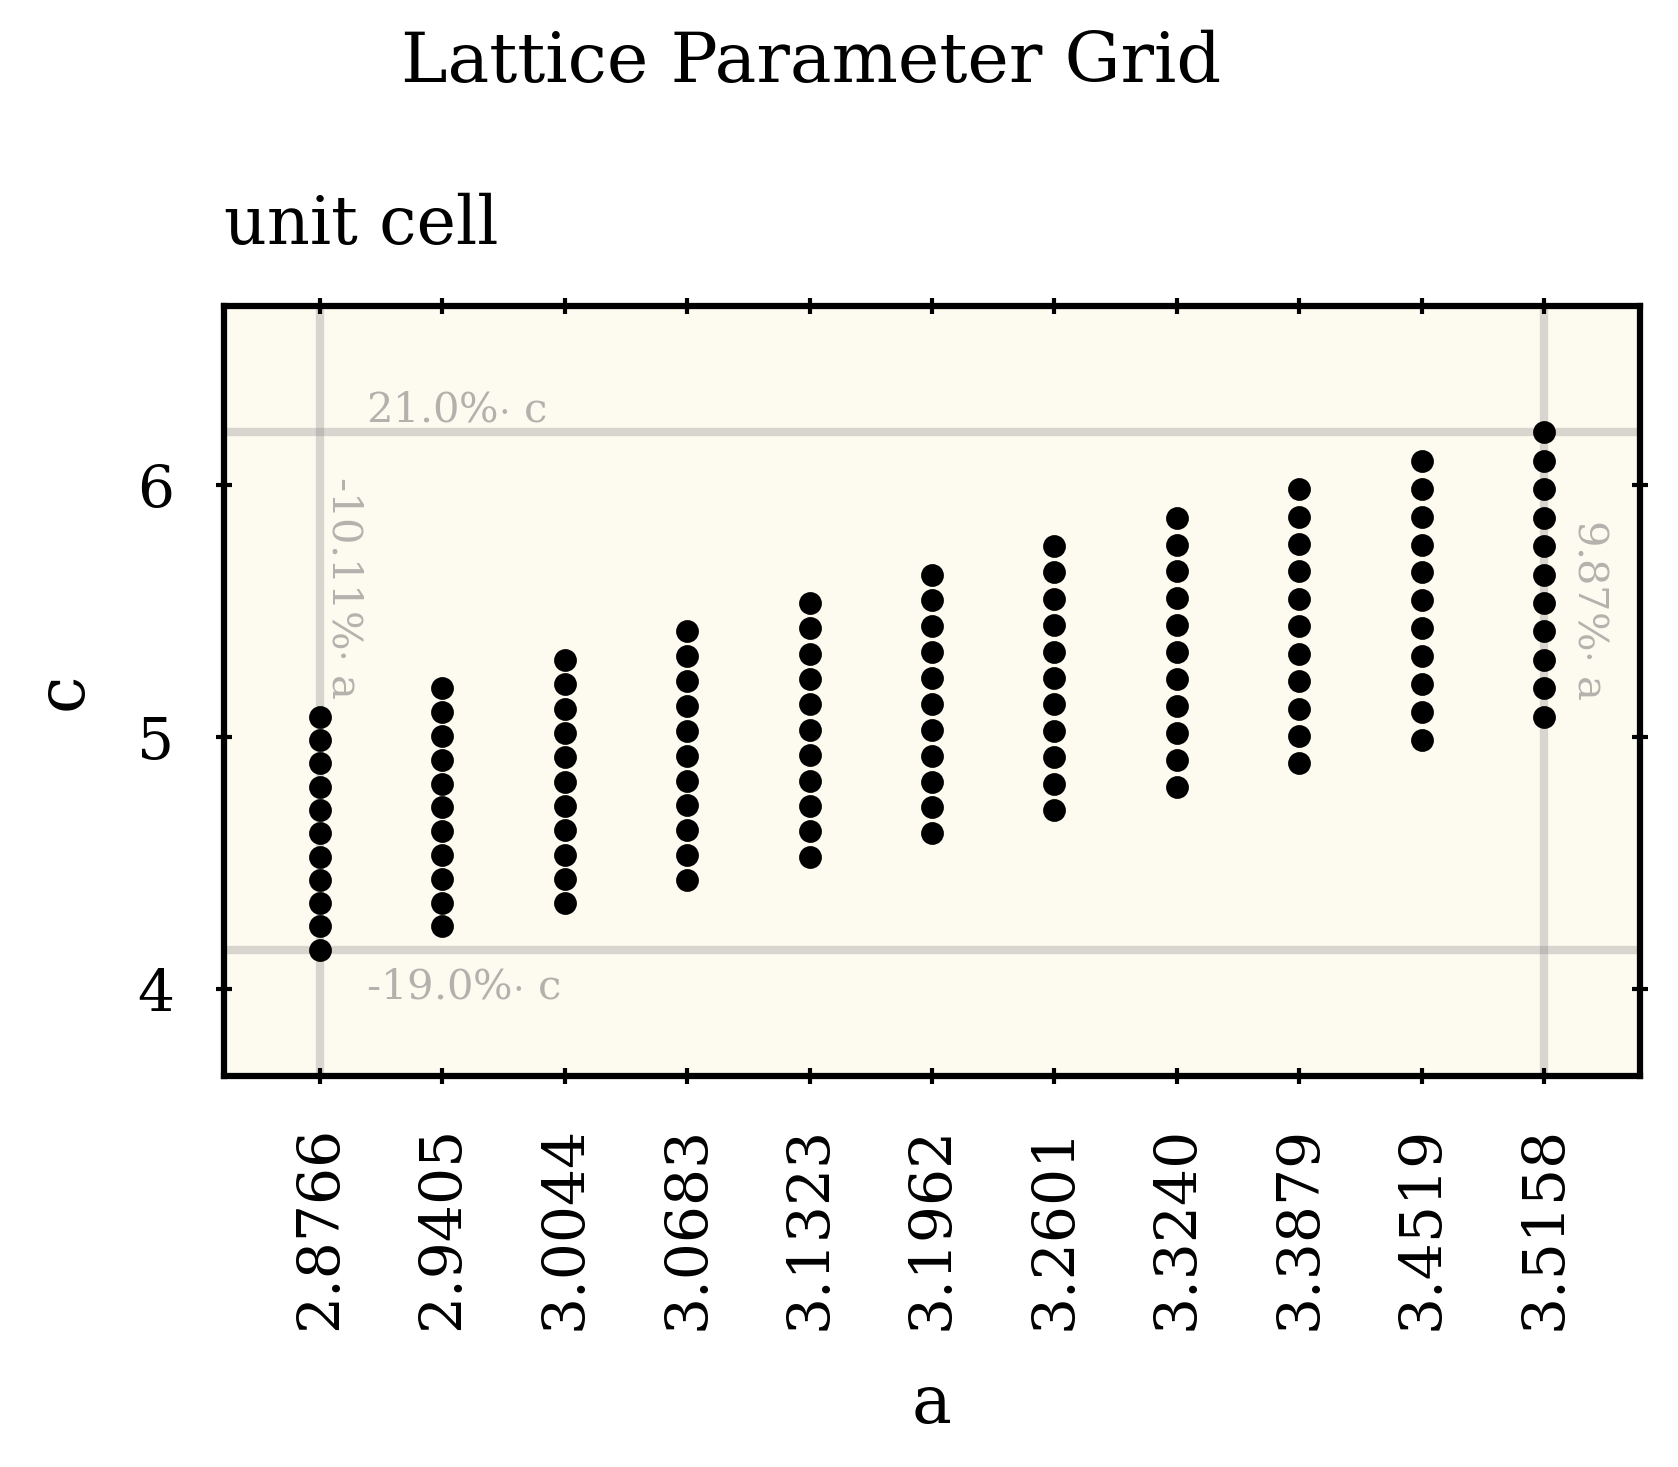

In [12]:
fig, ax = plt.subplots(dpi=300)
fig.suptitle("Lattice Parameter Grid")
ax.set_title("unit cell", pad=15, loc="left")
df_unit_cell.plot(kind="scatter", x="a", y="c", ax=ax, color="black")
ax.set_xticks(unique_a)

ax.set_ylim([cmin - 0.5, cmax + 0.5])
ax.set_xlim([amin - 0.05, amax + 0.05])

ax.tick_params(axis="x", rotation=90)
ax.tick_params(axis="both", which="minor", length=0)
ax.tick_params(axis="both", which="major", length=4, direction="inout")

# Lattice parameter a
lines_style = dict(color="gray", alpha=0.3, ls="-", zorder=0)
text_style = dict(rotation=-90, color="dimgray", alpha=0.5, size=10)

text_min = f"{min_strain_a:.2f}%" + r"$\cdot$" + " a"
text_max = f"{max_strain_a:.2f}%" + r"$\cdot$" + " a"

ax.axvline(amin, **lines_style)
ax.axvline(amax, **lines_style)
ax.text(transform=ax.transAxes, x=0.07, y=0.5, s=text_min, **text_style)
ax.text(transform=ax.transAxes, x=0.95, y=0.5, s=text_max, **text_style)


# Lattice parameter c
text_style = dict(rotation=0, color="dimgrey", alpha=0.5, size=10)
lines_style = dict(color="gray", alpha=0.3, ls="-",zorder=0)

text_min = f"{min_strain_c:.1f}%" + r"$\cdot$" + " c"
text_max = f"{max_strain_c:.1f}%" + r"$\cdot$" + " c"

ax.axhline(cmin, **lines_style)
ax.axhline(cmax, **lines_style)

ax.text(transform=ax.transAxes, x=0.10, y=0.10, s=text_min, **text_style)
ax.text(transform=ax.transAxes, x=0.10, y=0.85, s=text_max, **text_style)
# ax.text(transform=ax.transAxes, x=0.10, y=0.80)

plt.show()

Pelo visto eu criei um strain meio maluco... no plano parece ir de -10% a 10%, na mas na vertical vai de -19% a 21% mas com valores diferentes para cada $a$ comprimido/esticado!

In [13]:
df_unit_cell.drop(columns="atoms").to_csv("unit_cells.csv", index=False, sep=" ")


---